In [1]:
import torch
from torchsummary import summary
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchvision.models import vgg16_bn, VGG16_BN_Weights
from torch.nn.functional import one_hot
from torchvision.ops import roi_pool


from torchvision import transforms

from cvat_sdk import make_client
from cvat_sdk.pytorch import ProjectVisionDataset

In [2]:
IMAGE_SHAPE = (640, 640)
class RLETransform(torch.nn.Module):
    '''
    transforms CVAT data to proper objects of labels, bboxes and masks
    '''
    def forward(self, Target):
        labels = []
        bboxes = []
        masks = []
        
        for data in Target.annotations.shapes:
            # лейблы в датасете начинаются с 9. Нулевая метка занята под фон. 
            # Поэтому все метки надо сдвинуть на 8 влево
            labels.append(data['label_id']-8)
            
            bboxes_raw = data['points'][-4:]
            # y1, x1, y2, x2
            bboxes.append([bboxes_raw[1], bboxes_raw[0], bboxes_raw[3], bboxes_raw[2]])
            
            masks.append(self.rle_to_mask(data['points'][:-4], bboxes[-1]))

        return labels, bboxes, masks

    
    def rle_to_mask(self, rle, bbox):
        height = int(bbox[2]-bbox[0])+1
        width  = int(bbox[3]-bbox[1])+1
        top = int(bbox[0])
        left = int(bbox[1])
        
        mask = np.zeros(width * height, dtype=np.uint8)
        
        rle.insert(0,0.0)
        rle_pairs = np.array(rle, dtype=np.uint32)
        
        pos = 0
        for i in range(0, len(rle_pairs), 2):
            start = pos
            end = pos + int(rle_pairs[i])
            mask[start:end] = 1  # Устанавливаем пиксели в белый цвет (255)
            pos = end + int(rle_pairs[i + 1])  # Пропускаем следующие пиксели
        
        
        return torch.unsqueeze(torch.from_numpy(mask.reshape((height, width))), dim=0)

## создаем датасет из загруженных с CVAT данных

In [3]:
class_dict = {
    1: 'Apple',
    2: 'Hurma',
    3: 'Orange',
    4: 'Pear',
    5: 'Kiwi',
    6: 'Tangerine'
}

# log into the CVAT server
with make_client(host="http://10.162.1.50:8080", credentials=('admin', 'qaedwsrf123')) as client:
    # get the dataset comprising all tasks for the Validation subset of project 12345
    dataset = ProjectVisionDataset(client, project_id=2,
                                  transform = transforms.ToTensor(),
                                  target_transform = RLETransform())

train_size = len(dataset) - 50
val_size = 50

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

BS = 1

# train_dataset = DataLoader(train_dataset, batch_size=BS, shuffle=True)
# val_dataset = DataLoader(val_dataset, batch_size=BS, shuffle=False)

print(f'train size: {len(train_dataset)}; val size: {len(val_dataset)}')

Server version '2.30.1' is not compatible with SDK version '2.32.0'. Some SDK functions may not work properly with this server. You can continue using this SDK, or you can try to update with 'pip install cvat-sdk'.


train size: 601; val size: 50


In [4]:
problems = []
for i in range(len(dataset)):
    try:
        _,_ = dataset[i]
    except:
        problems.append(i)

problems

[]

In [5]:
# im, trgt = next(iter(train_dataset))

# a,b,c  = trgt

# b

In [6]:
class Spine(nn.Module):
    def __init__(self, vgg):
        super(Spine, self).__init__()
        
        for i, child in enumerate(vgg.children()):
            for param in child.parameters():
                param.requires_grad = False
                
            if i == 0:
                layers_list = child
        
        self.conv = nn.Sequential(*layers_list[:-1])

    def forward(self, x):

        x = self.conv(x)

        return x
    

In [7]:
DETECTION_CLASSES = 6
# !!!! класс с индексом 0 - задний фон !!!!
class СlassifierHead(nn.Module):
    def __init__(self):
        super(СlassifierHead, self).__init__()

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(in_features = 8192, out_features = 2048, bias=True),
            nn.BatchNorm1d(2048, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 2048, out_features = 2048, bias=True),
            nn.BatchNorm1d(2048, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 2048, out_features = 1024, bias=True),
            nn.BatchNorm1d(1024, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 1024, out_features = 512, bias=True),
            nn.BatchNorm1d(512, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 512, out_features = DETECTION_CLASSES + 1, bias=True),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)

        return x

class ClsTrainer(СlassifierHead):
    def __init__(self,
                lr,
                criterion):
        super(ClsTrainer, self).__init__()

        self.lr = lr
        self.optim = torch.optim.Adam(super().parameters(), lr=self.lr)
        self.criterion = criterion
        self.epo_train_losses = []
        self.epo_val_losses = []
        
        self.train_losses = []
        self.val_losses = []

    def train_step(self, batch, target):
        self.train()
        self.optim.zero_grad()
        
        output = self.forward(batch)
        loss = self.criterion(output, target)

        loss.backward()
        self.optim.step()

        self.epo_train_losses.append(loss.item())

    def eval_step(self, batch, target):
        output = self.query(batch)
        loss = self.criterion(output, target)
        self.epo_val_losses.append(loss.item())

    def query(self, batch):
        self.eval()
        with torch.no_grad():
            output = self.forward(batch)

        return output

    def epoch_end(self):
        self.train_losses.append(np.mean(self.epo_train_losses))
        self.val_losses.append(np.mean(self.epo_val_losses))

        self.epo_train_losses = []
        self.epo_val_losses = []

In [8]:
class RegressorHead(nn.Module):
    def __init__(self):
        super(RegressorHead, self).__init__()

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Sequential(
            nn.Linear(in_features = 8192, out_features = 1024, bias=True),
            nn.BatchNorm1d(1024, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features = 1024+4, out_features = 512, bias=True),
            nn.BatchNorm1d(512, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            
            nn.Linear(in_features = 512, out_features = 256, bias=True),
            nn.BatchNorm1d(256, momentum = 0.8),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(in_features = 256, out_features = 4, bias=True)
        )

    def forward(self, sample, P):
        x = self.flatten(sample)
        x = self.fc1(x)
        x = torch.cat((x, P), dim=-1)
        x = self.fc2(x)

        return x


class RgsTrainer(RegressorHead):
    def __init__(self,
                lr,
                criterion):
        super(RgsTrainer, self).__init__()

        self.lr = lr
        self.optim = torch.optim.Adam(super().parameters(), lr=self.lr)
        self.criterion = criterion
        self.epo_train_losses = []
        self.epo_val_losses = []
        
        self.train_losses = []
        self.val_losses = []

    def train_step(self, batch, target):
        self.train()
        self.optim.zero_grad()

        input1, input2 = batch
        output = self.forward(input1, input2)
        loss = self.criterion(output, target)

        loss.backward()
        self.optim.step()

        self.epo_train_losses.append(loss.item())

    def eval_step(self, batch, target):
        output = self.query(batch)
        loss = self.criterion(output, target)
        self.epo_val_losses.append(loss.item())

    def query(self, batch):
        self.eval()
        with torch.no_grad():
            input1, input2 = batch
            output = self.forward(input1, input2)

        return output

    def epoch_end(self):
        self.train_losses.append(np.mean(self.epo_train_losses))
        self.val_losses.append(np.mean(self.epo_val_losses))

        self.epo_train_losses = []
        self.epo_val_losses = []

In [9]:
ROI_SHAPE = (8,8)
# возможно стоит перевести к входному размеру 14 на 14 и выходному в 56 на 56
class SegmentHead(nn.Module):
    def __init__(self):
        super(SegmentHead, self).__init__()
        self.relu = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()
        self.to_standart_mask = transforms.Resize((96,96))

        self.conv1 = nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2)
        self.BN1 = nn.BatchNorm2d(256, momentum = 0.8)
        
        self.conv2 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2)
        self.BN2 = nn.BatchNorm2d(128, momentum = 0.8)

        self.conv3 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2)
        self.BN3 = nn.BatchNorm2d(64, momentum = 0.8)

        self.conv4 = nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2)
        self.BN4 = nn.BatchNorm2d(32, momentum = 0.8)

        self.conv5 = nn.Conv2d(32, DETECTION_CLASSES, kernel_size=5, stride=1)


    def forward(self, x):
        x = self.conv1(x)
        x = self.BN1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.BN2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.BN3(x)
        x = self.relu(x)

        x = self.conv4(x, output_size=(146,146))
        x = self.BN4(x)
        x = self.relu(x)

        x = self.conv5(x)
        x = self.to_standart_mask(x)
        x = self.sigmoid(x)

        return x


class SgmTrainer(SegmentHead):
    def __init__(self,
                lr,
                criterion):
        super(SgmTrainer, self).__init__()

        self.lr = lr
        self.optim = torch.optim.Adam(super().parameters(), lr=self.lr)
        self.criterion = criterion
        self.epo_train_losses = []
        self.epo_val_losses = []
        
        self.train_losses = []
        self.val_losses = []

    def train_step(self, batch, target):
        self.train()
        self.optim.zero_grad()
        
        output = self.forward(batch)
        loss = self.criterion(output, target)

        loss.backward()
        self.optim.step()

        self.epo_train_losses.append(loss.item())

    def eval_step(self, batch, target):
        output = self.query(batch)
        loss = self.criterion(output, target)
        self.epo_val_losses.append(loss.item())

    def query(self, batch):
        self.eval()
        with torch.no_grad():
            output = self.forward(batch)

        return output

    def epoch_end(self):
        self.train_losses.append(np.mean(self.epo_train_losses))
        self.val_losses.append(np.mean(self.epo_val_losses))

        self.epo_train_losses = []
        self.epo_val_losses = []

In [34]:
def get_GT_of_bbox(bbox, GT_bboxes, GT_labels, overlap=0.3):
    '''
    computing ground truth labels of given bbox in original image cordinates
    '''
    x1, y1, x2, y2 = bbox
    bbox_area = (x2 - x1) * (y2 - y1)
    if bbox_area == 0:
        return 0
    
    max_overlap = 0
    best_id = 0
    best_bbox = None
    
    for gt_bbox, label in zip(GT_bboxes, GT_labels):
        gt_x1, gt_y1, gt_x2, gt_y2 = gt_bbox
        
        # Вычисляем координаты пересечения
        inter_x1 = max(x1, gt_x1)
        inter_y1 = max(y1, gt_y1)
        inter_x2 = min(x2, gt_x2)
        inter_y2 = min(y2, gt_y2)
        
        # Вычисляем ширину и высоту пересечения
        inter_width = inter_x2 - inter_x1
        inter_height = inter_y2 - inter_y1
        
        # Если пересечение существует
        if inter_width > 0 and inter_height > 0:
            inter_area = inter_width * inter_height
            overlap_ratio = inter_area / bbox_area
            
            # Проверяем условие на минимальное пересечение и сравниваем с текущим максимальным пересечением
            if overlap_ratio >= overlap and inter_area > max_overlap:
                max_overlap = inter_area
                best_id = label
                best_bbox = gt_bbox
    
    return best_id, best_bbox

# класс всей mask r-cnn целиком
class Segment:
    def __init__(
        self,
        device,
        spine,
        
        classifier,
        regressor, 
        segmentator,
    ):
        self.device = device
        
        self.spine = spine
        self.spine.eval()
        
        self.classifier = classifier
        self.regressor = regressor
        self.segmentator = segmentator


    # лучше это переоформить как связку хребта и классификатора
    def spine_to_classifier(self, batch, mode='train', targets=None, boxes=None):
        # getting image features
        with torch.no_grad():
            sample = self.spine(batch.to(self.device))

        # getting classifier labels for each achor_box of single image in batch
        BATCH = 0
            
        ancors_batch = sample[BATCH, :, boxes[0,0]:boxes[0,2], boxes[0,1]:boxes[0,3]]
        ancors_batch = torch.unsqueeze(ancors_batch, dim=0)
        
        for i in range(1, len(boxes)):
            batch_element = sample[BATCH, :, boxes[i,0]:boxes[i,2], boxes[i,1]:boxes[i,3]]
            batch_element = torch.unsqueeze(batch_element, dim=0)
            
            ancors_batch = torch.cat((ancors_batch, batch_element), dim=0)


        # отправляем полученный батч в классификатор
        if mode == 'train':
            self.classifier.train_step(ancors_batch.detach(), targets.float().to(self.device))

            return sample, ancors_batch, None
        elif mode == 'query':
            classifierHead_response = self.classifier.query(ancors_batch.detach())

            # от classifierHead_response ищем лосс и делаем step при обучении
            # сделать метод для сопоставления места ancor_box и места bbox из GT
        
            verdict = torch.argmax(classifierHead_response, dim=1).cpu()
            
            # признаки изображения и класс каждого маленького бокса общей нумерации
            return sample, ancors_batch, verdict
        elif mode == 'eval':
            self.classifier.eval_step(ancors_batch.detach(), targets.float().to(self.device))

            return sample, ancors_batch, None


    def foreground_to_regressor(self, boxes_features, positions, mode='train', targets=None):
        if mode == 'train':
            self.regressor.train_step((boxes_features.detach(), positions), targets)

            return None
        elif mode == 'query':
            transforms = self.regressor.query((boxes_features, positions))

            return transforms
        elif mode == 'eval':
            self.regressor.eval_step((boxes_features.detach(), positions), targets)

            return None

    def roi_to_segmentator(self, roi_features, mode='train', targets=None):
        if mode == 'train':
            self.segmentator.train_step(roi_features.detach(), targets)

            return None
        elif mode == 'query':
            masks = self.segmentator.query(roi_features)

            return masks
        elif mode == 'eval':
            self.segmentator.eval_step(roi_features.detach(), targets)

            return None
        

    # здесь будем определять GT для всех голов и вызывать их в нужном режиме
    def train_step(self, image, targets, mode='train'):
        GT_labels, GT_bboxes, GT_masks = targets
        image = torch.unsqueeze(image, dim=0).to(self.device)

        # создаем тензор с координатами боксов на тензоре признаков sample
        sample_boxes = [torch.unsqueeze(el, dim=0) for el in self.anchor_boxes()]
        sample_boxes = torch.cat(sample_boxes, dim=0)

        # собираем истинные метки классов всех ancor_box и, если они не фон, их истинные размеры
        ancor_boxes_GT_labels = []
        bboxes_GT = []
        small_bboxes_ind = []

        # переходим в большие координаты
        image_boxes = self.image_bbox_cords(sample_boxes)
        for ind, image_box in enumerate(image_boxes):
            GT_label, GT_bbox = get_GT_of_bbox(image_box, GT_bboxes, GT_labels)
            
            ancor_boxes_GT_labels.append(GT_label)
            if GT_label != 0:
                bboxes_GT.append(GT_bbox)
                small_bboxes_ind.append(ind)
                
        # истинные значения боксов в больших координатах
        bboxes_GT = torch.tensor(bboxes_GT).to(self.device)
        #идексы коробок которые имеют истинную метку не фона
        small_bboxes_ind = torch.tensor(small_bboxes_ind)
        
        # истинные метки классов всех ancor_box
        ancor_boxes_GT_labels = torch.tensor(ancor_boxes_GT_labels)
        ancor_boxes_GT_labels = one_hot(ancor_boxes_GT_labels, num_classes=DETECTION_CLASSES+1)


        # positions в координатах признаков
        sample, boxes_features, verdict = self.spine_to_classifier(image, 
                                                                   mode=mode, 
                                                                   targets=ancor_boxes_GT_labels, 
                                                                   boxes=sample_boxes)



        # Классификатор отработал. Ищем истинные трансформации для не фоновых боксов
        # Примечание: регрессор обучается на истинных данных, а не на даных основанных 
        # на работе классификатора. При рабочем режиме модели boxes_features и positions
        # пойдут в регрессор на прямую
    

        
        regressor_targets = self.get_GT_transforms(sample_boxes[small_bboxes_ind].to(self.device), bboxes_GT)

        transforms = self.foreground_to_regressor(boxes_features[small_bboxes_ind], 
                                                  sample_boxes[small_bboxes_ind].to(self.device),
                                                  mode=mode,
                                                  targets=regressor_targets)

        # transforms будем применять к sample_boxes[verdict!=0] при рабочем режиме
        # при обучении воспользуемся regressor_targets примененными к sample_boxes[small_bboxes_ind]

        GT_bboxes = torch.tensor(GT_bboxes).to(self.device)
        ROI_boxes = torch.cat((torch.zeros((GT_bboxes.shape[0], 1)).to(self.device), GT_bboxes), dim=-1)
        # в сегментатор на обучении подаем GT боксы. Выделяем данные для него по уточненным коробкам
        ROI_samples = roi_pool(sample, boxes=ROI_boxes, output_size=ROI_SHAPE, spatial_scale=1.0/16.0)

        GT_masks = self.get_GT_masks(GT_masks, GT_labels)
        sampled_masks = self.roi_to_segmentator(ROI_samples, 
                                                mode=mode,
                                                targets=GT_masks.to(self.device))

        
        
    # вызываем train_step для всех элементов датасета
    def train(self, train_dataset, val_dataset, epoches=1):
        for epo in tqdm(range(epoches)):
            for i in torch.randperm(len(train_dataset)):
                image, targets = train_dataset[i]
                self.train_step(image, targets, mode='train')

            for image, targets in val_dataset:
                self.train_step(image, targets, mode='eval')

            self.classifier.epoch_end()
            self.regressor.epoch_end()
            self.segmentator.epoch_end()


    # вызываем все головы в рабочем режиме
    def __call__(self, image):
        mode = 'query'
        image = torch.unsqueeze(image, dim=0).to(self.device)

        # создаем тензор с координатами боксов на тензоре признаков sample
        sample_boxes = [torch.unsqueeze(el, dim=0) for el in self.anchor_boxes()]
        sample_boxes = torch.cat(sample_boxes, dim=0)

        # positions в координатах признаков
        sample, boxes_features, verdict = self.spine_to_classifier(image, 
                                                                   mode=mode,
                                                                   boxes=sample_boxes)
        
        boxes_features = boxes_features[verdict!=0]
        sample_boxes = sample_boxes[verdict!=0].to(self.device)
        transforms = self.foreground_to_regressor(boxes_features, 
                                                  sample_boxes,
                                                  mode=mode)

        sample_boxes = self.apply_transforms(sample_boxes, transforms)

        ROI_boxes = torch.cat((torch.zeros((sample_boxes.shape[0], 1)).to(self.device), sample_boxes), dim=-1)
        # в сегментатор на обучении подаем GT боксы. Выделяем данные для него по уточненным коробкам
        ROI_samples = roi_pool(sample, boxes=ROI_boxes, output_size=ROI_SHAPE, spatial_scale=1.0/16.0)


        sampled_masks = self.roi_to_segmentator(ROI_samples, 
                                                mode=mode)

        return verdict[verdict!=0], sample_boxes, sampled_masks


        

        

    def image_bbox_cords(self, bbox, scale_factor=16):
        bbox = bbox*scale_factor
        return bbox

    def sample_bbox_cords(self, bbox, scale_factor=0.0625):
        bbox = bbox*scale_factor
        return bbox

    @staticmethod
    def anchor_boxes(sample_size = (40,40), box_size = (4,4), stride = 4):
        '''
        returns all boxes by parameters y_top, x_left, y_bot, x_right
        box tensor will be: sample[BATCH, :, box[0]:box[2], box[1]:box[3]]
        '''
        for y in range(0, sample_size[0], stride):
            for x in range(0, sample_size[1], stride):
                yield torch.tensor([y,x,y+box_size[0],x+box_size[1]])

    # ancor_box в маленьких координатах, bboxes_GT в больших
    def get_GT_transforms(self, ancor_box, bboxes_GT):
        '''
        transform cordinates of sample
        '''
        ancor_box_GT = self.sample_bbox_cords(bboxes_GT)
        
        transforms_GT = torch.zeros_like(ancor_box_GT)
        
        # t_x = (G_x - P_x)/P_w
        transforms_GT[:, 0] = (ancor_box_GT[:,0]-ancor_box[:,0])/ancor_box[:,2]
    
        # t_y = (G_y - P_y)/P_h
        transforms_GT[:, 1] = (ancor_box_GT[:,1]-ancor_box[:,1])/ancor_box[:,3]
        
        # t_w = ln(G_w/P_w)
        transforms_GT[:, 2] = torch.log(ancor_box_GT[:,2]/ancor_box[:,2])
        
        # t_h = ln(G_h/P_h)
        transforms_GT[:,3] = torch.log(ancor_box_GT[:,3]/ancor_box[:,3])
    
        return transforms_GT

    # применяем корректироваки регрессора
    def apply_transforms(self, ancor_box, transforms):
        bbox_output = torch.zeros_like(ancor_box, dtype=torch.float)
    
        # G_x = t_x*P_w + P_x
        bbox_output[:, 0] = transforms[:,0]*ancor_box[:,2] + ancor_box[:,0]
    
        # G_y = t_y*P_h + P_y
        bbox_output[:, 1] = transforms[:,1]*ancor_box[:,3] + ancor_box[:,1]
        
        # G_w = exp(t_w)*P_w
        bbox_output[:, 2] = torch.exp(transforms[:,2])*ancor_box[:,2]
        
        # G_h = exp(t_h)*P_h
        bbox_output[:, 3] = torch.exp(transforms[:,3])*ancor_box[:,3]
    
        return bbox_output

    # фона здесь уже нет, метки классов сдвигаются на 1. Нулевая маска отображает 1 класс
    def get_GT_masks(self, raw_masks, GT_labels):
        resize = transforms.Resize((96,96))
        GT_masks = torch.zeros((len(raw_masks), DETECTION_CLASSES, 96, 96)).float()

        for ind, raw_mask in enumerate(raw_masks):
            GT_masks[ind, GT_labels[ind]-1, :, :] = resize(raw_mask)

        return GT_masks

    def to(self, device):
        self.device = device
        self.spine.to(device)
        self.classifier.to(device)
        self.regressor.to(device)
        self.segmentator.to(device)
                

In [179]:
def dice_coefficient(pred_mask: torch.Tensor, true_mask: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    assert pred_mask.shape == true_mask.shape, "Размеры pred_mask и true_mask должны совпадать"
    
    # Вычисляем пересечение и суммы
    intersection = (pred_mask * true_mask).sum(dim=(2, 3))
    pred_sum = pred_mask.sum(dim=(2, 3))
    true_sum = true_mask.sum(dim=(2, 3))
    
    # Вычисляем коэффициент Дайса
    dice = (2. * intersection + eps) / (pred_sum + true_sum + eps)
    
    return dice

def segmentation_loss(output, target):
    BCE = torch.nn.BCELoss()
    return BCE(output, target) - 0.4*torch.log(dice_coefficient(output, target))

In [180]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

print(device)

spine = Spine(vgg16_bn(weights = VGG16_BN_Weights.IMAGENET1K_V1)).to(device)


class_weights = torch.tensor([0.05, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]).to(device)
classifier_criterion = torch.nn.BCELoss(weight = class_weights)

classifier = ClsTrainer(lr = 0.0005, criterion = classifier_criterion).to(device)


regressor_criterion = nn.SmoothL1Loss()
regressor = RgsTrainer(lr = 0.005, criterion = regressor_criterion).to(device)


segmentator = SgmTrainer(lr = 0.001, criterion = torch.nn.BCELoss()).to(device)

cuda:0


In [181]:
args = {
    'device': device,
    'spine': spine,
    'classifier': classifier,
    'regressor': regressor,
    'segmentator': segmentator
}

RCNN = Segment(**args)

In [182]:
RCNN.train(train_dataset, val_dataset, epoches=6)

  0%|          | 0/6 [00:00<?, ?it/s]

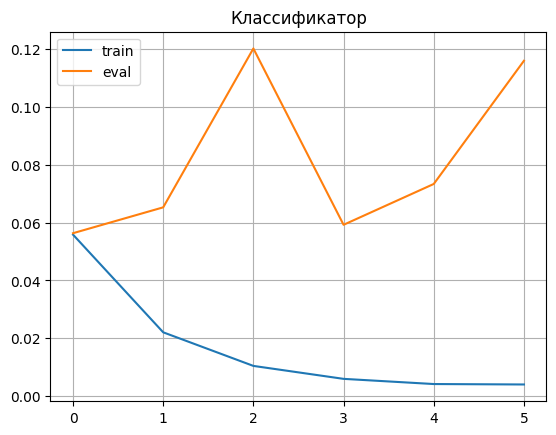

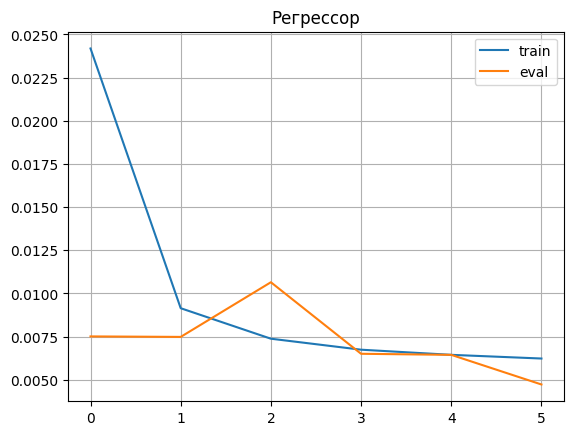

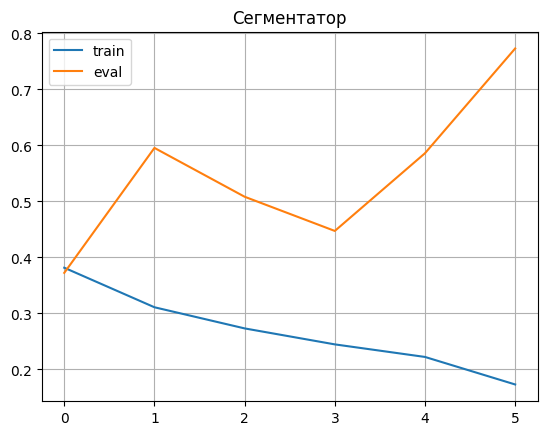

In [183]:
def show_losses(RCNN):
    plt.figure(1)
    plt.plot(RCNN.classifier.train_losses, label='train')
    plt.plot(RCNN.classifier.val_losses, label='eval')
    plt.title("Классификатор")
    plt.legend()
    plt.grid(True)
    
    plt.figure(2)
    plt.plot(RCNN.regressor.train_losses, label='train')
    plt.plot(RCNN.regressor.val_losses, label='eval')
    plt.title("Регрессор")
    plt.legend()
    plt.grid(True)
    
    plt.figure(3)
    plt.plot(RCNN.segmentator.train_losses, label='train')
    plt.plot(RCNN.segmentator.val_losses, label='eval')
    plt.title("Сегментатор")
    plt.legend()
    plt.grid(True)

show_losses(RCNN)

In [184]:
image_ind = 13
RCNN.to('cpu')
verdict, sample_boxes, sampled_masks = RCNN(val_dataset[image_ind][0])

In [185]:
sample_boxes.shape, verdict.shape, sampled_masks.shape

(torch.Size([7, 4]), torch.Size([7]), torch.Size([7, 6, 96, 96]))

['Pear', 'Pear', 'Pear', 'Apple', 'Pear', 'Apple', 'Pear']

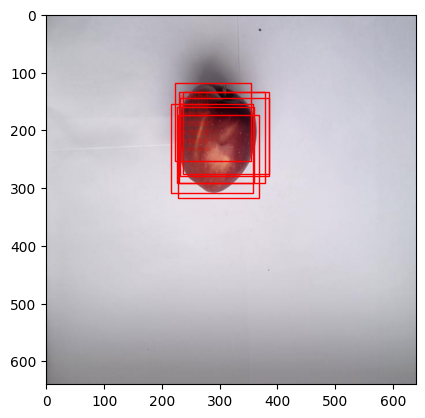

In [186]:
import matplotlib.patches as patches

image = torch.permute(val_dataset[image_ind][0], (1,2,0))


raw_masks = sampled_masks[torch.arange(sampled_masks.size(0)),verdict-1, :,:]
sample_boxes[sample_boxes<0] = 0
sample_boxes[sample_boxes>39.9375] = 39.9

rects = []
alpha = 0.3
for label, bbox, mask in zip((verdict-1).cpu(), (sample_boxes*16).int().cpu(), raw_masks.cpu()):
    try:
        resize = transforms.Resize((int(bbox[2])-int(bbox[0]), (int(bbox[3])-int(bbox[1]))))
        scaled_mask = resize(torch.unsqueeze(mask, dim=0))[0]
        real_mask = torch.zeros_like(scaled_mask)
        real_mask[scaled_mask>0.5] = 1
    
        appled_mask = torch.zeros((640,640))


        appled_mask[bbox[0]:bbox[2], bbox[1]:bbox[3]] = real_mask

    
        image[appled_mask==1] = (1-alpha)*image[appled_mask==1] + alpha*torch.tensor([1.0, 0.0, 0.0])

        rects.append(patches.Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], linewidth=1, edgecolor='r', facecolor='none'))
    except:
        print(bbox)

    
    



fig, ax = plt.subplots()

ax.imshow(image)
for rect in rects:
    ax.add_patch(rect)

lst = []
for label in verdict:
    lst.append(class_dict[label.item()])
lst

torch.Size([189, 138]) tensor([120, 226, 308, 363], dtype=torch.int32)


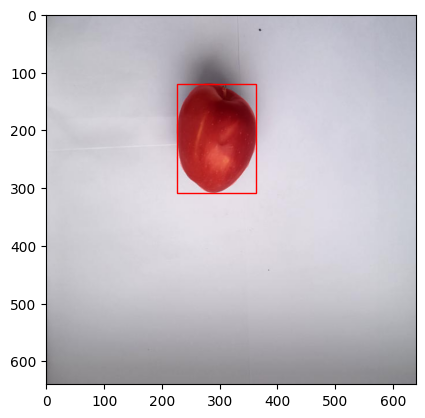

In [187]:
labels, bboxes, masks = val_dataset[image_ind][1]
image = torch.permute(val_dataset[image_ind][0], (1,2,0))

rects = []
for bbox, mask in zip(bboxes, masks):
    rects.append(patches.Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], linewidth=1, edgecolor='r', facecolor='none'))

    appled_mask = torch.zeros((640,640))

    bbox_int = torch.tensor(bbox).int()
    print(mask[0].shape, bbox_int)
    
    appled_mask[bbox_int[0]:bbox_int[2]+1, bbox_int[1]:bbox_int[3]+1] = mask[0]


    image[appled_mask==1] = (1-alpha)*image[appled_mask==1] + alpha*torch.tensor([1.0, 0.0, 0.0])
    
fig, ax = plt.subplots()

ax.imshow(image)
for rect in rects:
    ax.add_patch(rect)

In [20]:
# явно прослеживается проблема с семплированием боксов
# -> датасет подает боксы в порядке y,x,y,x -> регрессор работает корректно, классификатор укладывается 
# в рамки ожидаемого при условии сильного дисбаланса с фоновыми изображениями
# сегментатор совершенно не учится, стоит попробовать уменьшить размер выходной маски и увеличить размер входной


# отображение результатов                        работает корректно
# методы get_GT_transforms и apply_transforms    работают корректно
# метод get_GT_of_bbox                           работает корректно


In [21]:
# def draw_raw_results()